In [17]:
from pathlib import Path
import jax.numpy as np
from jax import config
from jax.lax import broadcast_in_dim
config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from gwfast.gwfastGlobals import detectors as det_dict, detPath, MRSUN_SI, MTSUN_SI, uGpc, DAY_TO_SEC
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import BasicGWSignal, AGNLensedGWSignal, GeneralLensedGWSignal
import gwfast.network as network
from gwfast.lensing_utils import (
    get_agn_lensed_parameters,
    get_agn_lens_angles,
    PML_time_delay_magnification,
    dLGridGlob, zGridGlob, einstein_angle
)

from pycbc.filter import match
from pycbc.types.frequencyseries import FrequencySeries

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

In [18]:
def PML_simple_lens_parameters(parameters):
    output_params = parameters.copy()
    luminosity_distance = output_params.pop("dL")

    theta_E, beta, lens_mass_src = get_agn_lens_angles(
        output_params['M_lz'], output_params['R_orbit'], 
        output_params['src_pos'], luminosity_distance
    )
    time_delay, mag_1, mag_2 = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)

    output_params['delta_time'] = time_delay * lens_mass_src * MTSUN_SI / DAY_TO_SEC  # Days (tcoal)
    output_params['dL_1'] = luminosity_distance / np.sqrt(np.abs(mag_1))
    output_params['dL_2'] = luminosity_distance / np.sqrt(np.abs(mag_2))
    output_params['delta_iota']    = np.zeros_like(mag_1)  # No change in iota
    output_params['delta_phase']   = np.zeros_like(mag_1)  # No change in phi
    output_params['delta_psi']     = np.zeros_like(mag_1)  # No change in psi
    output_params['relative_mass'] = np.ones_like(mag_1)  # No change in mass
    return output_params

In [19]:
def convert_y_to_src_pos(y, R_orbit, rs=1):
    # Convert source position from units of Einstein radius to units of R_orbit
    # Returns a 2D grid of src_pos with shape (len(y), len(R_orbit))
    Dls_min = (np.sqrt(np.square(R_orbit) + np.power(y, 4)) - np.square(y)) * rs # for rs=1, this is in units of R_S
    theta_E = np.sqrt(2 * Dls_min) # Einstein radius in units of R_S
    src_pos = np.outer(y, theta_E / R_orbit)
    return src_pos

In [20]:
def inner_product(frequencies, h1, h2, psd):
    integrand = np.conj(h1) * h2 / psd
    return 4 * np.real(np.trapezoid(integrand, frequencies, axis=0))

def mismatch(frequencies, h1, h2, psd):
    # Ranges from 0 to 1
    return inner_product(frequencies, h1-h2, h1-h2, psd) / (2 * (inner_product(frequencies, h1, h1, psd) + inner_product(frequencies, h2, h2, psd)))

# def mismatch(frequencies, h1, h2, psd):
#     # Ranges from 0 to 2
#     return 1 - inner_product(frequencies, h1, h2, psd) / np.sqrt(inner_product(frequencies, h1, h1, psd) * inner_product(frequencies, h2, h2, psd))

In [21]:
# Set up detector
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')

wf_model = waveforms.IMRPhenomD()

L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
L1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [22]:
# Define a benchmark event
n = 100
shape = n
events = {
    'Mc': 30, 'eta': 0.24, 'iota': 0.99*np.pi/2, 'phase': 2,
    'chi1z': 0.3, 'chi2z': 0.5, 'tcoal': 0,
    'R_orbit': 100, 'M_lz': 1e4, 'src_pos': 0.2,
    'dL': 1, 'psi': 4, 'theta': 1.87, 'phi': 2.66,
}
events = {key: np.full(shape, val).astype(np.float64) for key, val in events.items()}

# Sample parameter space
R_orbit_array = np.geomspace(10, 1e4, n)
params = events.copy()
params['R_orbit'] = R_orbit_array

general_lensed_params = L1_AGN.convert_to_general_lensed_parameters(params)
simple_lensed_params = PML_simple_lens_parameters(params)

only_rel_mass_params = general_lensed_params.copy()
only_rel_mass_params['Mc'] = np.full(shape, params['Mc'])

# # Fix y in Einstein radii for the first two event copies
# y_const_array = np.full(n, 0.5) # in Einstein radii
# src_pos_grid = convert_y_to_src_pos(y_const_array, R_orbit_array)

In [23]:
# Waveform metadata
sampling_frequency = 2048.  # Hz
duration = 8.  # s
f_min = 10.
f_max = sampling_frequency / 2

# This procedure to create coupled time and freq arrays is borrowed from Bilby
N_samples = int(np.round(duration * sampling_frequency))
N_freq_bins = int(np.round(N_samples / 2) + 1)
freq_array = np.linspace(0, sampling_frequency / 2, N_freq_bins)
time_array = np.linspace(0, duration - 1 / sampling_frequency, N_samples)

freq_mask = (freq_array >= f_min) & (freq_array <= f_max)
masked_freq_arr = freq_array[freq_mask]
freq_grid = broadcast_in_dim(freq_array, (N_freq_bins, shape), (0,))
masked_freq_grid = broadcast_in_dim(masked_freq_arr, (masked_freq_arr.size, shape), (0,))

cplx_zeros = np.zeros((freq_array.size, shape), dtype=np.complex128)
# Make use of jax numpy `.at.set` copying feature
full_AGN_strain = cplx_zeros.at[freq_mask].set(L1_Lensed.GWstrain(masked_freq_grid, general_lensed_params))
simple_lensed_strain = cplx_zeros.at[freq_mask].set(L1_Lensed.GWstrain(masked_freq_grid, simple_lensed_params))
only_rel_mass_strain = cplx_zeros.at[freq_mask].set(L1_Lensed.GWstrain(masked_freq_grid, only_rel_mass_params))

psd_interp = np.interp(freq_array, L1.psd_frequencies, L1.psd_array)
psd_interp_grid = broadcast_in_dim(psd_interp, (N_freq_bins, shape), (0,))

In [27]:
delta_f = freq_grid[1, 0]-freq_grid[0, 0]
psd_FD = FrequencySeries(psd_interp, delta_f=delta_f, epoch=0)

mismatch_pycbc_full_AGN = np.zeros(n)
for i in range(n):
    full_AGN_strain_slice = full_AGN_strain[:, i]
    simple_lensed_strain_slice = simple_lensed_strain[:, i]
    full_AGN_strain_slice_FD = FrequencySeries(full_AGN_strain_slice, delta_f=delta_f, epoch=0)
    simple_lensed_strain_slice_FD = FrequencySeries(simple_lensed_strain_slice, delta_f=delta_f, epoch=0)

    match_pycbc, _ = match(full_AGN_strain_slice_FD, simple_lensed_strain_slice_FD, psd=psd_FD, low_frequency_cutoff=f_min)
    mismatch_pycbc_full_AGN = mismatch_pycbc_full_AGN.at[i].set(1 - match_pycbc)

mismatch_only_rel_mass = mismatch(freq_grid, simple_lensed_strain, only_rel_mass_strain, psd_interp_grid)

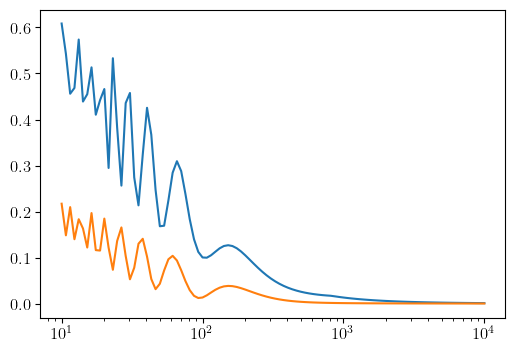

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(R_orbit_array, mismatch_pycbc_full_AGN, label='Full AGN vs Simple Lens')
ax.plot(R_orbit_array, mismatch_only_rel_mass, label='Simple Lens vs Only Rel Mass')
ax.set_xscale('log')